In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
os.environ['OMP_NUM_THREADS'] = '1'

import torch
torch.set_num_threads(1)
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report
from torch.utils.data import Dataset, DataLoader

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DATA = Path('../../data/processed')
MODELS = Path('../../data/models')
DEVICE = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'PyTorch {torch.__version__} | Device: {DEVICE}')

PyTorch 2.10.0 | Device: mps


In [3]:
WINDOW = 48
HORIZON = 12
MIN_SEQ_LEN = WINDOW + HORIZON + 10
N_FEATURES = 4

prices = pd.read_parquet(DATA / 'prices.parquet')
print(f'Загружено: {len(prices):,} точек, {prices.token_id.nunique()} рынков')

def create_features(price_series):
    df = pd.DataFrame({'price': price_series.values})
    df['ret'] = df['price'].diff().fillna(0)
    df['vol'] = df['ret'].rolling(12, min_periods=1).std().fillna(0)
    df['momentum'] = df['price'] - df['price'].rolling(12, min_periods=1).mean()
    df['momentum'] = df['momentum'].fillna(0)
    return df[['price', 'ret', 'vol', 'momentum']].values

def create_sequences(prices_df, window=WINDOW, horizon=HORIZON):
    all_X, all_y = [], []
    for token_id, group in prices_df.groupby('token_id'):
        ts = group.sort_values('datetime')
        if len(ts) < MIN_SEQ_LEN:
            continue
        features = create_features(ts['price'])
        prices_arr = ts['price'].values
        for i in range(0, len(features) - window - horizon, 6):
            X = features[i : i + window]
            current_price = prices_arr[i + window - 1]
            future_price = prices_arr[i + window + horizon - 1]
            y = 1.0 if future_price > current_price else 0.0
            all_X.append(X)
            all_y.append(y)
    return np.array(all_X, dtype=np.float32), np.array(all_y, dtype=np.float32)

X, y = create_sequences(prices)
print(f'Dataset: X={X.shape}, y={y.shape}')
print(f'Class balance: UP={y.mean():.1%}, DOWN={1-y.mean():.1%}')

Загружено: 1,681,266 точек, 1000 рынков


Dataset: X=(270589, 48, 4), y=(270589,)
Class balance: UP=33.4%, DOWN=66.6%


In [4]:
n = len(X)
train_end = int(n * 0.7)
val_end = int(n * 0.85)

X_train, y_train = X[:train_end], y[:train_end]
X_val, y_val = X[train_end:val_end], y[train_end:val_end]
X_test, y_test = X[val_end:], y[val_end:]

train_mean = X_train.reshape(-1, N_FEATURES).mean(axis=0)
train_std = X_train.reshape(-1, N_FEATURES).std(axis=0) + 1e-8

X_train_norm = (X_train - train_mean) / train_std
X_val_norm = (X_val - train_mean) / train_std
X_test_norm = (X_test - train_mean) / train_std

print(f'Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}')
print(f'\nФормат LSTM: (batch, seq_len={WINDOW}, features={N_FEATURES})')
print(f'Формат CNN:  (batch, channels={N_FEATURES}, seq_len={WINDOW})  ← transpose!')

Train: 189,412 | Val: 40,588 | Test: 40,589

Формат LSTM: (batch, seq_len=48, features=4)
Формат CNN:  (batch, channels=4, seq_len=48)  ← transpose!


In [5]:
class TimeSeriesDataset(Dataset):
    """Dataset с поддержкой CNN формата (channels first)."""
    def __init__(self, X, y, channels_first=False):
        self.X = torch.tensor(X, dtype=torch.float32)
        if channels_first:

            self.X = self.X.transpose(1, 2)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

BATCH_SIZE = 256

train_ds = TimeSeriesDataset(X_train_norm, y_train, channels_first=True)
val_ds = TimeSeriesDataset(X_val_norm, y_val, channels_first=True)
test_ds = TimeSeriesDataset(X_test_norm, y_test, channels_first=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE * 2)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE * 2)

batch_X, batch_y = next(iter(train_loader))
print(f'CNN Batch X: {batch_X.shape}  → (batch, channels={N_FEATURES}, seq_len={WINDOW})')
print(f'CNN Batch y: {batch_y.shape}')

CNN Batch X: torch.Size([256, 4, 48])  → (batch, channels=4, seq_len=48)
CNN Batch y: torch.Size([256])


In [6]:
np.random.seed(SEED)
momentum_prob = 1 / (1 + np.exp(-X_test[:, -6:, 1].sum(axis=1) * 50))
mr_prob = 1 - momentum_prob

results = {}
results['Random'] = {'auc': 0.5, 'acc': 0.5}
results['Mean Reversion'] = {
    'auc': roc_auc_score(y_test, mr_prob),
    'acc': accuracy_score(y_test, (X_test[:, -1, 1] < 0).astype(float))
}

results['LSTM (nb03)'] = {'auc': 0.6598, 'acc': 0.678}
results['GRU (nb03)'] = {'auc': 0.6661, 'acc': 0.678}

print('Baselines и LSTM результаты для сравнения:')
for name, m in results.items():
    print(f'  {name:<20} AUC={m["auc"]:.4f}  Acc={m["acc"]:.1%}')

Baselines и LSTM результаты для сравнения:
  Random               AUC=0.5000  Acc=50.0%
  Mean Reversion       AUC=0.5585  Acc=66.4%
  LSTM (nb03)          AUC=0.6598  Acc=67.8%
  GRU (nb03)           AUC=0.6661  Acc=67.8%


In [7]:
class PriceCNN(nn.Module):
    """1D CNN для предсказания направления цены."""

    def __init__(self, in_channels=4, dropout=0.3):
        super().__init__()

        self.conv1 = nn.Sequential(
            nn.Conv1d(in_channels, 32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),
        )
        self.conv2 = nn.Sequential(
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),
        )
        self.conv3 = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
        )

        self.gap = nn.AdaptiveAvgPool1d(1)

        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(128, 1)
        )

    def forward(self, x):

        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.gap(x)
        x = x.squeeze(-1)
        return self.classifier(x).squeeze(-1)

    def get_feature_maps(self, x):
        """Возвращает feature maps после каждого блока (для визуализации)."""
        with torch.no_grad():
            f1 = self.conv1(x)
            f2 = self.conv2(f1)
            f3 = self.conv3(f2)
            return f1, f2, f3

model = PriceCNN(in_channels=N_FEATURES).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f'PriceCNN: {total_params:,} параметров')
print(f'\nАрхитектура:')
print(model)

with torch.no_grad():
    out = model(batch_X.to(DEVICE))
    print(f'\nForward: {batch_X.shape} → {out.shape}')

print(f'\nReceptive field: ~23 из 48 timesteps (48%)')
print(f'Сравнение: LSTM видит ВСЕ 48 шагов, но CNN параллелен.')

PriceCNN: 36,513 параметров

Архитектура:
PriceCNN(
  (conv1): Sequential(
    (0): Conv1d(4, 32, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv3): Sequential(
    (0): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (gap): AdaptiveAvgPool1d(output_size=1)
  (classifier): Sequential(
    (0): Dropout(p=0.3, inplace=False)
    (1): Linear(in_features=128, out_features=1, bias=True)
  )
)



Forward: torch.Size([256, 4, 48]) → torch.Size([256])

Receptive field: ~23 из 48 timesteps (48%)
Сравнение: LSTM видит ВСЕ 48 шагов, но CNN параллелен.


In [8]:
criterion = nn.BCEWithLogitsLoss()

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        total_loss += loss.item() * len(y_batch)
        all_preds.append(torch.sigmoid(logits).cpu().numpy())
        all_labels.append(y_batch.cpu().numpy())
    preds = np.concatenate(all_preds)
    labels = np.concatenate(all_labels)
    avg_loss = total_loss / len(labels)
    auc = roc_auc_score(labels, preds)
    acc = accuracy_score(labels, (preds > 0.5).astype(int))
    return avg_loss, auc, acc, preds, labels

def train_model(model, name, epochs=20, lr=1e-3, patience=5):
    """Train model with early stopping, return test metrics."""
    model = model.to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=3, factor=0.5)
    best_auc = 0
    no_improve = 0
    history = {'train_loss': [], 'val_loss': [], 'val_auc': []}

    for epoch in range(epochs):
        model.train()
        total_loss, n = 0, 0
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
            opt.zero_grad()
            loss = criterion(model(X_b), y_b)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            total_loss += loss.item() * len(y_b)
            n += len(y_b)

        train_loss = total_loss / n
        val_loss, val_auc, val_acc, _, _ = evaluate(model, val_loader)
        sched.step(val_loss)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_auc'].append(val_auc)

        improved = val_auc > best_auc
        if improved:
            best_auc = val_auc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1

        lr_now = opt.param_groups[0]['lr']
        print(f'  Epoch {epoch+1:2d}/{epochs} | Train: {train_loss:.4f} | '
              f'Val: {val_loss:.4f} | AUC: {val_auc:.4f} | LR: {lr_now:.1e} '
              f'{"★" if improved else ""}')

        if no_improve >= patience:
            print(f'  Early stopping at epoch {epoch+1}')
            break

    model.load_state_dict(best_state)
    test_loss, test_auc, test_acc, preds, labels = evaluate(model, test_loader)
    print(f'  → {name}: Val AUC={best_auc:.4f} | Test AUC={test_auc:.4f} | Acc={test_acc:.1%}')
    return model, test_auc, test_acc, history, preds

print('Training utilities ready.')

Training utilities ready.


In [9]:
print('=== PriceCNN (baseline) ===')
cnn_model, cnn_auc, cnn_acc, cnn_history, cnn_preds = train_model(
    PriceCNN(in_channels=N_FEATURES), 'PriceCNN', epochs=20
)
results['CNN (baseline)'] = {'auc': cnn_auc, 'acc': cnn_acc}

torch.save(cnn_model.state_dict(), MODELS / 'price_cnn_v1.pt')

=== PriceCNN (baseline) ===


  Epoch  1/20 | Train: 0.6182 | Val: 0.6220 | AUC: 0.6249 | LR: 1.0e-03 ★


  Epoch  2/20 | Train: 0.6083 | Val: 0.6208 | AUC: 0.6330 | LR: 1.0e-03 ★


  Epoch  3/20 | Train: 0.6039 | Val: 0.6150 | AUC: 0.6426 | LR: 1.0e-03 ★


  Epoch  4/20 | Train: 0.6021 | Val: 0.6138 | AUC: 0.6447 | LR: 1.0e-03 ★


...

  Epoch  9/20 | Train: 0.5984 | Val: 0.6144 | AUC: 0.6440 | LR: 1.0e-03 


  Epoch 10/20 | Train: 0.5982 | Val: 0.6124 | AUC: 0.6465 | LR: 1.0e-03 


  Epoch 11/20 | Train: 0.5976 | Val: 0.6122 | AUC: 0.6464 | LR: 5.0e-04 


  Epoch 12/20 | Train: 0.5958 | Val: 0.6214 | AUC: 0.6383 | LR: 5.0e-04 
  Early stopping at epoch 12


  → PriceCNN: Val AUC=0.6477 | Test AUC=0.6685 | Acc=67.9%


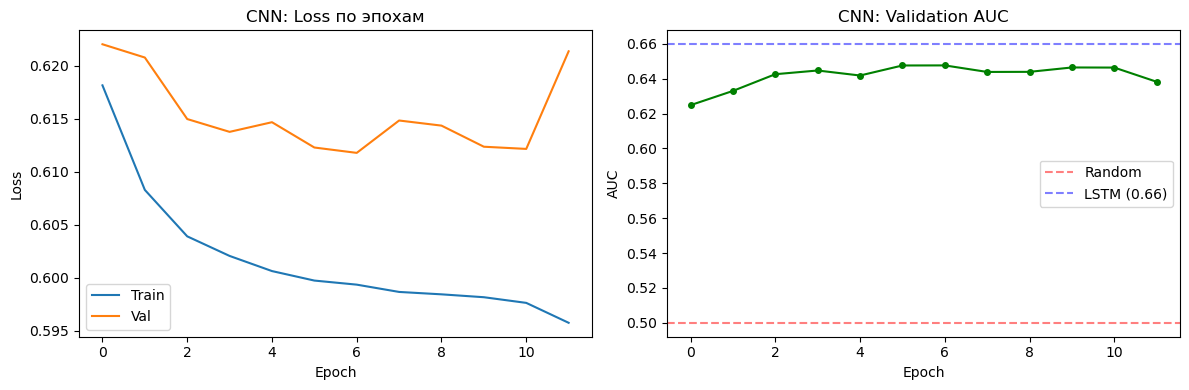

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(cnn_history['train_loss'], label='Train')
axes[0].plot(cnn_history['val_loss'], label='Val')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('CNN: Loss по эпохам')
axes[0].legend()

axes[1].plot(cnn_history['val_auc'], 'g-o', markersize=4)
axes[1].axhline(0.5, color='red', linestyle='--', alpha=0.5, label='Random')
axes[1].axhline(0.6598, color='blue', linestyle='--', alpha=0.5, label='LSTM (0.66)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('AUC')
axes[1].set_title('CNN: Validation AUC')
axes[1].legend()

plt.tight_layout(); plt.show()

In [11]:
test_loss, test_auc, test_acc, test_preds_cnn, test_labels = evaluate(cnn_model, test_loader)

print(f'=== CNN Test Results ===')
print(f'AUC:      {test_auc:.4f}')
print(f'Accuracy: {test_acc:.1%}')
print(f'Loss:     {test_loss:.4f}')
print(f'\nClassification Report:')
print(classification_report(test_labels, (test_preds_cnn > 0.5).astype(int),
                          target_names=['DOWN (0)', 'UP (1)']))

=== CNN Test Results ===
AUC:      0.6685
Accuracy: 67.9%
Loss:     0.5956

Classification Report:
              precision    recall  f1-score   support

    DOWN (0)       0.69      0.93      0.79     27072
      UP (1)       0.56      0.17      0.26     13517

    accuracy                           0.68     40589
   macro avg       0.63      0.55      0.53     40589
weighted avg       0.65      0.68      0.62     40589



In [12]:
class ResBlock(nn.Module):
    """Residual block: Conv → BN → ReLU → Conv → BN + skip → ReLU"""
    def __init__(self, channels, kernel_size=3):
        super().__init__()
        pad = kernel_size // 2
        self.block = nn.Sequential(
            nn.Conv1d(channels, channels, kernel_size, padding=pad),
            nn.BatchNorm1d(channels),
            nn.ReLU(),
            nn.Conv1d(channels, channels, kernel_size, padding=pad),
            nn.BatchNorm1d(channels),
        )

    def forward(self, x):
        return F.relu(self.block(x) + x)

class ResCNN(nn.Module):
    """CNN с residual connections."""
    def __init__(self, in_channels=4, dropout=0.3):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv1d(in_channels, 64, kernel_size=7, padding=3),
            nn.BatchNorm1d(64),
            nn.ReLU(),
        )

        self.res1 = ResBlock(64, kernel_size=3)
        self.pool1 = nn.MaxPool1d(2)
        self.res2 = ResBlock(64, kernel_size=3)
        self.pool2 = nn.MaxPool1d(2)
        self.res3 = ResBlock(64, kernel_size=3)

        self.gap = nn.AdaptiveAvgPool1d(1)
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.pool1(self.res1(x))
        x = self.pool2(self.res2(x))
        x = self.res3(x)
        x = self.gap(x).squeeze(-1)
        return self.classifier(x).squeeze(-1)

class MultiScaleCNN(nn.Module):
    """CNN с параллельными свёртками разного масштаба (Inception-style)."""
    def __init__(self, in_channels=4, dropout=0.3):
        super().__init__()

        self.branch_short = nn.Sequential(
            nn.Conv1d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
        )
        self.branch_mid = nn.Sequential(
            nn.Conv1d(in_channels, 32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
        )
        self.branch_long = nn.Sequential(
            nn.Conv1d(in_channels, 32, kernel_size=15, padding=7),
            nn.BatchNorm1d(32),
            nn.ReLU(),
        )

        self.merge = nn.Sequential(
            nn.Conv1d(96, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(2),
        )

        self.gap = nn.AdaptiveAvgPool1d(1)
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(128, 1)
        )

    def forward(self, x):

        s = self.branch_short(x)
        m = self.branch_mid(x)
        l = self.branch_long(x)

        x = torch.cat([s, m, l], dim=1)
        x = self.merge(x)
        x = self.gap(x).squeeze(-1)
        return self.classifier(x).squeeze(-1)

for name, cls in [('PriceCNN (baseline)', PriceCNN),
                   ('ResCNN (residual)', ResCNN),
                   ('MultiScaleCNN (inception)', MultiScaleCNN)]:
    m = cls(in_channels=N_FEATURES)
    n_params = sum(p.numel() for p in m.parameters())
    print(f'{name:<30}: {n_params:>8,} params')

PriceCNN (baseline)           :   36,513 params
ResCNN (residual)             :   76,929 params
MultiScaleCNN (inception)     :   47,201 params


In [13]:
print('\n=== ResCNN (residual connections) ===')
res_model, res_auc, res_acc, res_history, res_preds = train_model(
    ResCNN(in_channels=N_FEATURES), 'ResCNN', epochs=20
)
results['ResCNN'] = {'auc': res_auc, 'acc': res_acc}


=== ResCNN (residual connections) ===


  Epoch  1/20 | Train: 0.6188 | Val: 0.6194 | AUC: 0.6362 | LR: 1.0e-03 ★


  Epoch  2/20 | Train: 0.6036 | Val: 0.6135 | AUC: 0.6431 | LR: 1.0e-03 ★


  Epoch  3/20 | Train: 0.6000 | Val: 0.6135 | AUC: 0.6486 | LR: 1.0e-03 ★


  Epoch  4/20 | Train: 0.5984 | Val: 0.6120 | AUC: 0.6480 | LR: 1.0e-03 


...

  Epoch 14/20 | Train: 0.5933 | Val: 0.6117 | AUC: 0.6511 | LR: 1.0e-03 


  Epoch 15/20 | Train: 0.5927 | Val: 0.6131 | AUC: 0.6463 | LR: 1.0e-03 


  Epoch 16/20 | Train: 0.5926 | Val: 0.6117 | AUC: 0.6480 | LR: 5.0e-04 


  Epoch 17/20 | Train: 0.5900 | Val: 0.6123 | AUC: 0.6474 | LR: 5.0e-04 
  Early stopping at epoch 17


  → ResCNN: Val AUC=0.6539 | Test AUC=0.6754 | Acc=68.0%


In [14]:
print('\n=== MultiScaleCNN (inception-style) ===')
ms_model, ms_auc, ms_acc, ms_history, ms_preds = train_model(
    MultiScaleCNN(in_channels=N_FEATURES), 'MultiScaleCNN', epochs=20
)
results['MultiScaleCNN'] = {'auc': ms_auc, 'acc': ms_acc}


=== MultiScaleCNN (inception-style) ===


  Epoch  1/20 | Train: 0.6186 | Val: 0.6229 | AUC: 0.6194 | LR: 1.0e-03 ★


  Epoch  2/20 | Train: 0.6096 | Val: 0.6162 | AUC: 0.6367 | LR: 1.0e-03 ★


  Epoch  3/20 | Train: 0.6042 | Val: 0.6180 | AUC: 0.6345 | LR: 1.0e-03 


  Epoch  4/20 | Train: 0.6026 | Val: 0.6151 | AUC: 0.6425 | LR: 1.0e-03 ★


...

  Epoch 14/20 | Train: 0.5945 | Val: 0.6139 | AUC: 0.6442 | LR: 5.0e-04 


  Epoch 15/20 | Train: 0.5942 | Val: 0.6187 | AUC: 0.6363 | LR: 5.0e-04 


  Epoch 16/20 | Train: 0.5937 | Val: 0.6197 | AUC: 0.6341 | LR: 2.5e-04 


  Epoch 17/20 | Train: 0.5921 | Val: 0.6149 | AUC: 0.6436 | LR: 2.5e-04 
  Early stopping at epoch 17


  → MultiScaleCNN: Val AUC=0.6484 | Test AUC=0.6711 | Acc=67.5%


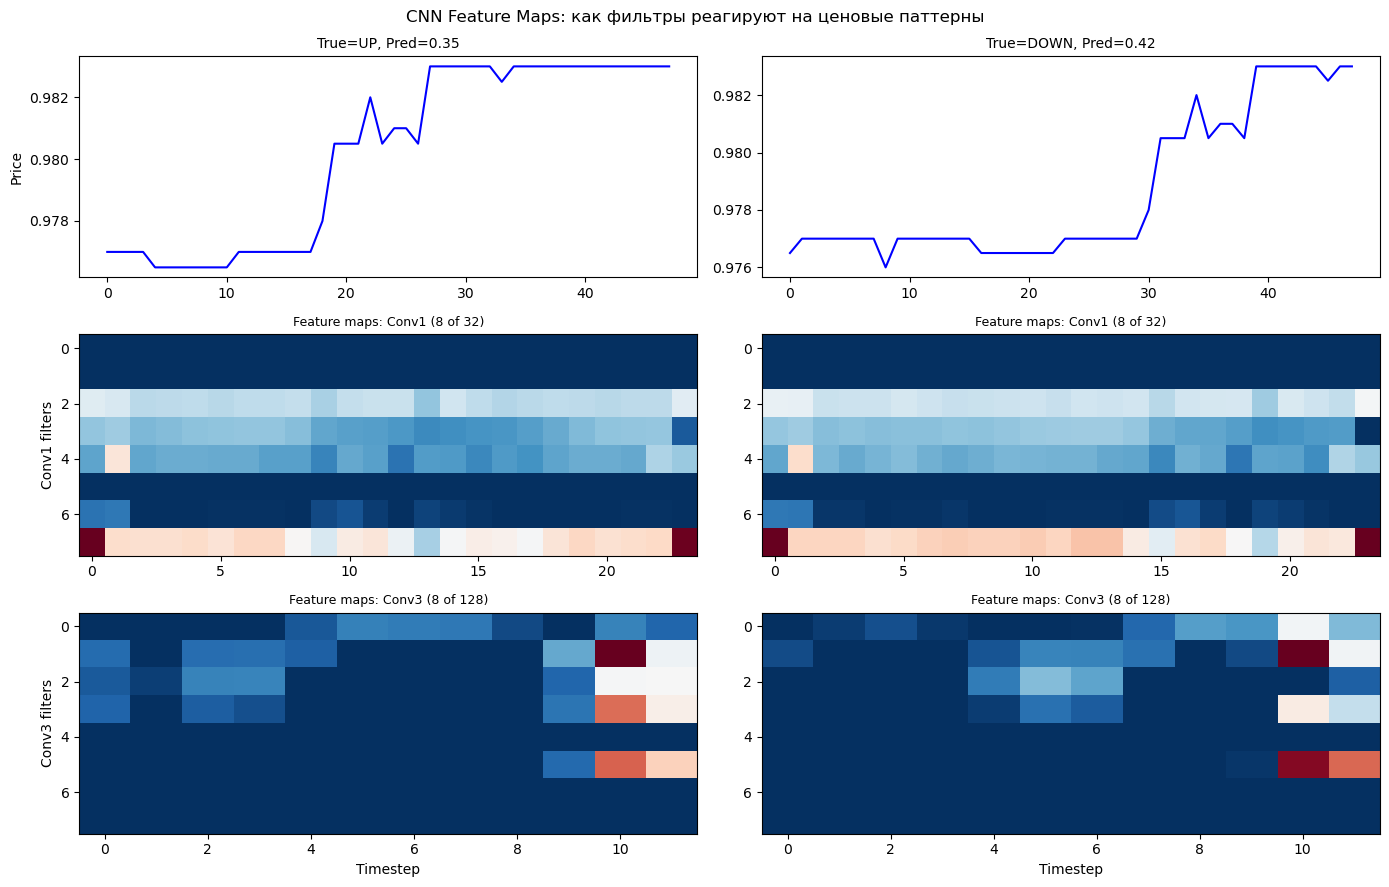

Conv1 ловит простые паттерны (edges, spikes), Conv3 — комбинации (тренды, развороты).


In [15]:
cnn_model.eval()

up_idx = np.where(y_test == 1)[0][0]
down_idx = np.where(y_test == 0)[0][0]

fig, axes = plt.subplots(3, 2, figsize=(14, 9))

for col, idx in enumerate([up_idx, down_idx]):

    seq_raw = X_test[idx]
    seq_norm = torch.tensor(X_test_norm[idx:idx+1], dtype=torch.float32)
    seq_cnn = seq_norm.transpose(1, 2).to(DEVICE)

    f1, f2, f3 = cnn_model.get_feature_maps(seq_cnn)
    label = 'UP' if y_test[idx] == 1 else 'DOWN'
    pred = test_preds_cnn[idx]

    axes[0, col].plot(seq_raw[:, 0], 'b-', linewidth=1.5)
    axes[0, col].set_title(f'True={label}, Pred={pred:.2f}', fontsize=10)
    axes[0, col].set_ylabel('Price' if col == 0 else '')

    im1 = axes[1, col].imshow(f1[0, :8].cpu().numpy(), aspect='auto', cmap='RdBu_r')
    axes[1, col].set_ylabel('Conv1 filters' if col == 0 else '')
    axes[1, col].set_title('Feature maps: Conv1 (8 of 32)', fontsize=9)

    im2 = axes[2, col].imshow(f3[0, :8].cpu().numpy(), aspect='auto', cmap='RdBu_r')
    axes[2, col].set_ylabel('Conv3 filters' if col == 0 else '')
    axes[2, col].set_xlabel('Timestep')
    axes[2, col].set_title('Feature maps: Conv3 (8 of 128)', fontsize=9)

plt.suptitle('CNN Feature Maps: как фильтры реагируют на ценовые паттерны', fontsize=12)
plt.tight_layout(); plt.show()
print('Conv1 ловит простые паттерны (edges, spikes), Conv3 — комбинации (тренды, развороты).')

In [16]:
test_ds_lstm = TimeSeriesDataset(X_test_norm, y_test, channels_first=False)
test_loader_lstm = DataLoader(test_ds_lstm, batch_size=BATCH_SIZE * 2)

lstm_path = MODELS / 'price_lstm_v1.pt'
if lstm_path.exists():

    class PriceLSTM(nn.Module):
        def __init__(self, input_size=4, hidden_size=64, num_layers=1, dropout=0.3):
            super().__init__()
            self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size,
                              num_layers=num_layers, batch_first=True,
                              dropout=dropout if num_layers > 1 else 0)
            self.classifier = nn.Sequential(
                nn.Linear(hidden_size, 32), nn.ReLU(),
                nn.Dropout(dropout), nn.Linear(32, 1))
        def forward(self, x):
            _, (h_n, _) = self.lstm(x)
            return self.classifier(h_n[-1]).squeeze(-1)

    lstm_model = PriceLSTM(input_size=N_FEATURES).to(DEVICE)
    lstm_model.load_state_dict(torch.load(lstm_path, weights_only=True))
    lstm_model.eval()

    lstm_preds = []
    with torch.no_grad():
        for X_b, _ in test_loader_lstm:
            logits = lstm_model(X_b.to(DEVICE))
            lstm_preds.append(torch.sigmoid(logits).cpu().numpy())
    lstm_preds = np.concatenate(lstm_preds)

    ensemble_preds = (test_preds_cnn + lstm_preds) / 2
    ensemble_auc = roc_auc_score(y_test, ensemble_preds)
    ensemble_acc = accuracy_score(y_test, (ensemble_preds > 0.5).astype(int))

    results['Ensemble (CNN+LSTM)'] = {'auc': ensemble_auc, 'acc': ensemble_acc}

    best_w_auc = 0
    best_w = 0.5
    for w in np.arange(0.1, 0.9, 0.05):
        ens = w * test_preds_cnn + (1 - w) * lstm_preds
        auc = roc_auc_score(y_test, ens)
        if auc > best_w_auc:
            best_w_auc = auc
            best_w = w

    weighted_preds = best_w * test_preds_cnn + (1 - best_w) * lstm_preds
    weighted_auc = roc_auc_score(y_test, weighted_preds)
    weighted_acc = accuracy_score(y_test, (weighted_preds > 0.5).astype(int))
    results['Weighted (CNN+LSTM)'] = {'auc': weighted_auc, 'acc': weighted_acc}

    print(f'LSTM AUC:     {roc_auc_score(y_test, lstm_preds):.4f}')
    print(f'CNN AUC:      {cnn_auc:.4f}')
    print(f'Ensemble AUC: {ensemble_auc:.4f} (simple avg)')
    print(f'Weighted AUC: {weighted_auc:.4f} (CNN={best_w:.2f}, LSTM={1-best_w:.2f})')

    corr = np.corrcoef(test_preds_cnn, lstm_preds)[0, 1]
    print(f'\nКорреляция CNN-LSTM предсказаний: {corr:.4f}')
    print('Чем ниже корреляция, тем полезнее ensemble.')
else:
    print('LSTM model not found — skip ensemble')

LSTM AUC:     0.6598
CNN AUC:      0.6685
Ensemble AUC: 0.6671 (simple avg)
Weighted AUC: 0.6687 (CNN=0.85, LSTM=0.15)

Корреляция CNN-LSTM предсказаний: 0.9319
Чем ниже корреляция, тем полезнее ensemble.


Model                            Accuracy          AUC
ResCNN                             0.6796       0.6754
MultiScaleCNN                      0.6752       0.6711
Weighted (CNN+LSTM)                0.6787       0.6687
CNN (baseline)                     0.6789       0.6685
Ensemble (CNN+LSTM)                0.6791       0.6671
GRU (nb03)                         0.6780       0.6661
LSTM (nb03)                        0.6780       0.6598
Mean Reversion                     0.6636       0.5585
Random                             0.5000       0.5000


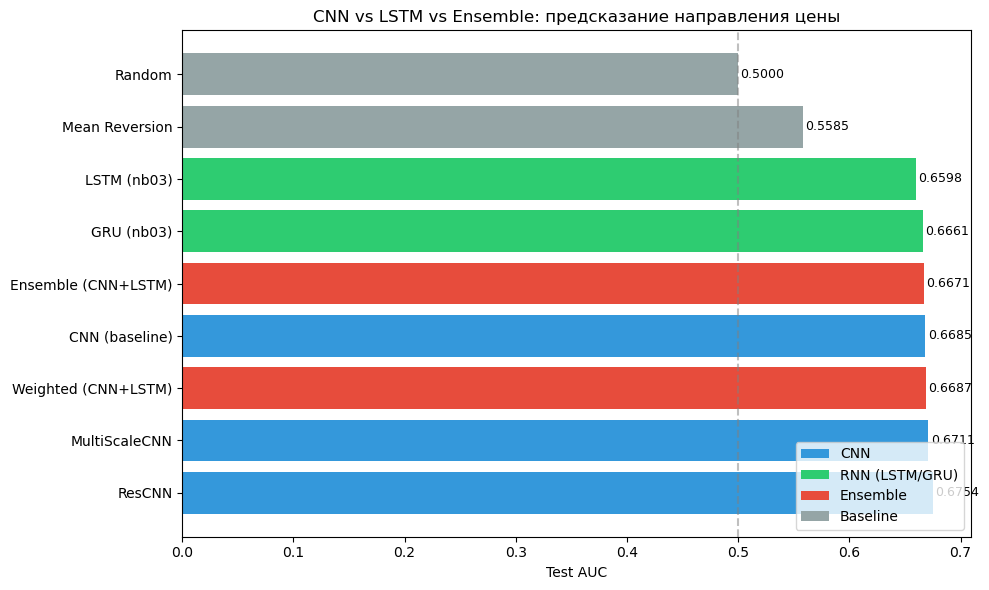

In [17]:
print('=' * 60)
print(f'{"Model":<28} {"Accuracy":>12} {"AUC":>12}')
print('=' * 60)

sorted_results = sorted(results.items(), key=lambda x: x[1]['auc'], reverse=True)
for name, metrics in sorted_results:
    print(f'{name:<28} {metrics["acc"]:>12.4f} {metrics["auc"]:>12.4f}')
print('=' * 60)

fig, ax = plt.subplots(figsize=(10, 6))
names = [r[0] for r in sorted_results]
aucs = [r[1]['auc'] for r in sorted_results]

def get_color(name):
    if 'Ensemble' in name or 'Weighted' in name:
        return '#e74c3c'
    elif 'CNN' in name or 'Res' in name or 'Multi' in name:
        return '#3498db'
    elif 'LSTM' in name or 'GRU' in name:
        return '#2ecc71'
    return '#95a5a6'

colors = [get_color(n) for n in names]
bars = ax.barh(names, aucs, color=colors)
ax.axvline(0.5, color='gray', linestyle='--', alpha=0.5, label='Random')
ax.set_xlabel('Test AUC')
ax.set_title('CNN vs LSTM vs Ensemble: предсказание направления цены')

for bar, auc in zip(bars, aucs):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{auc:.4f}', va='center', fontsize=9)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#3498db', label='CNN'),
    Patch(facecolor='#2ecc71', label='RNN (LSTM/GRU)'),
    Patch(facecolor='#e74c3c', label='Ensemble'),
    Patch(facecolor='#95a5a6', label='Baseline'),
]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout(); plt.show()